## Setup & Data Transformations

Single source of truth for the data, feature columns, targets, model hyperparameters,
CV splitter, and bootstrap bookkeeping reused by every section.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from scipy.stats import kruskal, spearmanr
from sklearn.feature_selection import RFECV
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    adjusted_rand_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GroupKFold, cross_val_predict

# Setup shared with `reviewer_response.ipynb` and `importance_significance.ipynb`.
from corona import (
    DATA_DIR,
    PARSI_6,
    PARSI_7,
    RANDOM_SEED,
    RandomForestClassifier,
    RandomForestRegressor,
    cluster_response,
    feature_cols,
    load_data,
    oof_permutation_importance,
    response_matrices,
    rf_kwargs,
)

In [2]:
df = load_data()

target_column = "enriched"
feature_columns = feature_cols(df)

proteins = df["entry"].reset_index(drop=True)
x = df.loc[:, feature_columns].reset_index(drop=True)
y = df.loc[:, target_column].reset_index(drop=True)
groups = proteins

print(
    f"n_samples={len(x)}, n_features={len(feature_columns)}, "
    f"n_proteins={groups.nunique()}, enriched_rate={y.mean():.3f}"
)

n_samples=6768, n_features=84, n_proteins=376, enriched_rate=0.391


In [3]:
# CV splitter and bootstrap constants used across every section. `rf_kwargs` (corona.py)
# serves both the classifier and the regressor.
N_FOLDS = 10
N_REPEATS = 10
N_BOOT = 500
TOP_K = 20

gkf = GroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Cluster-bootstrap bookkeeping: resample whole protein groups, keeping within-protein
# correlation structure (matches the GroupKFold logic).
unique_groups = groups.unique()
group_to_idx = {g: np.flatnonzero(groups.values == g) for g in unique_groups}

In [4]:
# Regression targets. Row-level log1p target for in-sample Gini importance, and the true
# leave-one-NP-out setup with the three abundance transforms.
y_reg_full = np.log1p(df["abundance"].values)

y_loo_raw = df["abundance"].values
groups_loo = df["npunid"].values
unique_nps_loo = np.unique(groups_loo)

min_nonzero = y_loo_raw[y_loo_raw > 0].min()
floor_value = min_nonzero / 2
loo_transforms = {
    "log1p": (np.log1p, np.expm1),
    "asinh": (np.arcsinh, np.sinh),
    "log2_floor": (
        lambda v: np.log2(np.where(v == 0, floor_value, v)),
        lambda v: np.where(v <= np.log2(floor_value), 0.0, np.power(2.0, v)),
    ),
}

print(f"n_NPs={len(unique_nps_loo)}")

n_NPs=18


In [5]:
# Curated parsimonious feature sets, imported from corona.py. PARSI_7 is the 1-SD
# parsimonious set from the enrichment-classifier RFECV (below); PARSI_6 drops
# `ligand_pei`, highly collinear with `zeta_potential` (Spearman ~0.82).
missing = [f for f in PARSI_7 if f not in feature_columns]
assert not missing, f"missing feature columns: {missing}"

## Helpers

Reusable functions shared across sections: cluster-bootstrap importances, importance
summary + top-K plot, RFECV 1-SD summary + curve, out-of-fold classifier metrics, and
the PDP/ICE grid. Dedicated
RNGs keep the bootstrap resampling and the ICE row-subsample reproducible regardless of
run order.


In [6]:
# Dedicated generator so the cluster-bootstrap resampling is reproducible regardless of
# execution order. PDP/ICE plots subsample ICE_SUBSAMPLE rows via the estimator's own
# random_state (sklearn's `subsample` takes an int count, not an index array).
boot_rng = np.random.default_rng(RANDOM_SEED)  # cluster-bootstrap resampling
ICE_SUBSAMPLE = 200  # number of ICE curves drawn per PDP panel


def cluster_bootstrap_importances(
    make_estimator, y_vec, n_boot=N_BOOT, require_two_classes=False
):
    """Resample whole protein groups with replacement, refit, collect Gini importances.

    `make_estimator(seed)` returns a fresh unfitted model. Returns an
    (n_boot, n_features) DataFrame of feature importances.
    """
    out = np.empty((n_boot, len(feature_columns)), dtype=np.float64)
    collected = 0
    while collected < n_boot:
        sampled = boot_rng.choice(unique_groups, size=len(unique_groups), replace=True)
        idx = np.concatenate([group_to_idx[g] for g in sampled])
        yb = y_vec[idx]
        if require_two_classes and np.unique(yb).size < 2:
            continue  # degenerate resample; essentially never happens with this data
        model = make_estimator(RANDOM_SEED + collected).fit(x.iloc[idx], yb)
        out[collected] = model.feature_importances_
        collected += 1
        if collected % 100 == 0:
            print(f"  bootstrap {collected}/{n_boot}")
    return pd.DataFrame(out, columns=feature_columns)


def build_importance_summary(observed, boot_df):
    """Observed Gini importances + bootstrap mean and 95% percentile CI, sorted."""
    return pd.DataFrame(
        {
            "observed": observed,
            "boot_mean": boot_df.mean(),
            "ci_low": boot_df.quantile(0.025),
            "ci_high": boot_df.quantile(0.975),
        }
    ).sort_values("observed", ascending=False)


def plot_topk_importance(summary, color, xlabel, title, k=TOP_K):
    """Horizontal bar chart of the top-k features with bootstrap-CI error bars."""
    top = summary.head(k)
    err_low = (top["observed"] - top["ci_low"]).clip(lower=0)
    err_high = (top["ci_high"] - top["observed"]).clip(lower=0)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(
        top.index[::-1],
        top["observed"][::-1],
        xerr=[err_low[::-1], err_high[::-1]],
        color=color,
        ecolor="black",
        capsize=3,
    )
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def rfecv_ks(rfecv):
    """(mean CV scores, across-fold SDs, best K, 1-SD parsimonious K) from a fitted RFECV.

    Scores are sklearn's (higher = better). The 1-SD K is the smallest K whose mean score is
    within one across-fold SD (not SE) of the best; valid for min_features_to_select=1, step=1.
    """
    scores = rfecv.cv_results_["mean_test_score"]
    stds = rfecv.cv_results_["std_test_score"]
    best = int(np.argmax(scores))
    parsi_k = int(np.flatnonzero(scores >= scores[best] - stds[best]).min() + 1)
    return scores, stds, best + 1, parsi_k


def plot_rfecv_curve(curve, stds, best_k, parsi_k, color, best_label, ylabel, title):
    """CV score vs feature count with +/- SD band, best K, 1-SD K and full-set baseline."""
    n = np.arange(1, len(curve) + 1)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(n, curve, marker="o", markersize=3, color=color)
    ax.fill_between(n, curve - stds, curve + stds, alpha=0.2, color=color)
    ax.axvline(best_k, color="green", ls="--", label=f"{best_label} K={best_k}")
    ax.axvline(parsi_k, color="orange", ls="--", label=f"1-SD K={parsi_k}")
    ax.axhline(curve[-1], color="gray", ls=":", label=f"full-set {curve[-1]:.3f}")
    ax.set_xlabel("Number of features")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def oof_classifier_metrics(features, return_preds=False):
    """GroupKFold-by-protein out-of-fold metrics for an RF classifier on `features`."""
    proba = cross_val_predict(
        RandomForestClassifier(**rf_kwargs),
        x[features],
        y,
        cv=gkf,
        groups=groups,
        n_jobs=-1,
        method="predict_proba",
    )[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "K": len(features),
        "roc_auc": roc_auc_score(y, proba),
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
    }
    return (proba, pred, metrics) if return_preds else metrics


def plot_pdp_ice(model, X, features, pd_color, title):
    """PDP (solid) + ICE (gray) grid for `features`, drawing ICE_SUBSAMPLE ICE curves."""
    ncols = (len(features) + 1) // 2
    fig, axes = plt.subplots(2, ncols, figsize=(16, 9))
    PartialDependenceDisplay.from_estimator(
        model,
        X,
        features=features,
        kind="both",
        subsample=ICE_SUBSAMPLE,
        ice_lines_kw={"alpha": 0.15, "linewidth": 0.5, "color": "tab:gray"},
        pd_line_kw={"color": pd_color, "linewidth": 2.5},
        ax=axes.ravel()[: len(features)],
        random_state=RANDOM_SEED,
    )
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()


DATA_DIR.mkdir(exist_ok=True)  # DATA_DIR = notebooks/data/, from corona.py


def export_csv(df, filename, index_name=None):
    """Save a result table to DATA_DIR/filename with no bare index column.

    `index_name` promotes a meaningful single-level index to a named column;
    a non-range index otherwise keeps its own name; a default RangeIndex is dropped.
    """
    out = df.copy()
    if index_name is not None:
        out = out.rename_axis(index_name).reset_index()
    elif not isinstance(out.index, pd.RangeIndex):
        out = out.reset_index()
    out.to_csv(DATA_DIR / filename, index=False)
    print(f"  {filename:48s} {out.shape[0]:>4d} x {out.shape[1]}")
    return DATA_DIR / filename


def export_shap_csv(shap_exp, stem):
    """Persist a SHAP Explanation so its beeswarm can be replotted without refitting.

    Writes two CSVs to DATA_DIR: `shap_{stem}_values.csv` (per-feature SHAP values, one
    row per sample) and `shap_{stem}_data.csv` (the matching feature values that color the
    beeswarm). Reload and replot with:
        v = pd.read_csv(DATA_DIR / f"shap_{stem}_values.csv")
        d = pd.read_csv(DATA_DIR / f"shap_{stem}_data.csv")
        exp = shap.Explanation(v.values, data=d.values, feature_names=list(v.columns))
        shap.plots.beeswarm(exp)
    """
    names = list(shap_exp.feature_names)
    export_csv(pd.DataFrame(shap_exp.values, columns=names), f"shap_{stem}_values.csv")
    export_csv(pd.DataFrame(shap_exp.data, columns=names), f"shap_{stem}_data.csv")

## RFR. Bootstrap Feature Importance

Cluster-bootstrap (resample protein groups, N=500) Gini importances for the abundance
regressor (`log1p` target) on the full feature set, with 95% percentile CIs, followed by
a Spearman correlation heatmap of the top-10 features.

In [7]:
# Single RF regressor fit on the full row-level data -> observed Gini importances.
rfr_full = RandomForestRegressor(**rf_kwargs).fit(x, y_reg_full)
observed_importance_reg = pd.Series(
    rfr_full.feature_importances_, index=feature_columns, name="importance"
).sort_values(ascending=False)

observed_importance_reg.head(20).to_frame()

,importance
abundance_controls,0.673807
zeta_potential,0.023262
nsp_secondary_structure_coil,0.019349
nsp_secondary_structure_helix,0.017753
dh_functionalized,0.014771
frac_aa_r,0.010341
incubation_concentration_mg_per_ml,0.007904
frac_aa_n,0.007472
frac_aa_m,0.006636
fraction_exposed_exposed_c,0.006628


In [8]:
# Cluster bootstrap by protein for the regressor (resample groups, refit, collect Gini).
boot_imp_reg_df = cluster_bootstrap_importances(
    lambda s: RandomForestRegressor(**{**rf_kwargs, "random_state": s}),
    y_reg_full,
)
importance_summary_reg = build_importance_summary(
    observed_importance_reg, boot_imp_reg_df
)
importance_summary_reg.head(20)

  bootstrap 100/500


  bootstrap 200/500


  bootstrap 300/500


  bootstrap 400/500


  bootstrap 500/500


,observed,boot_mean,ci_low,ci_high
abundance_controls,0.673807,0.623588,0.389254,0.815087
zeta_potential,0.023262,0.029907,0.013111,0.058983
nsp_secondary_structure_coil,0.019349,0.004718,0.000529,0.022222
nsp_secondary_structure_helix,0.017753,0.005620,0.000619,0.026200
dh_functionalized,0.014771,0.015168,0.009831,0.022348
frac_aa_r,0.010341,0.006286,0.000569,0.033743
incubation_concentration_mg_per_ml,0.007904,0.011806,0.005196,0.020938
frac_aa_n,0.007472,0.004514,0.000676,0.019298
frac_aa_m,0.006636,0.004935,0.000675,0.020398
fraction_exposed_exposed_c,0.006628,0.003603,0.000668,0.013291


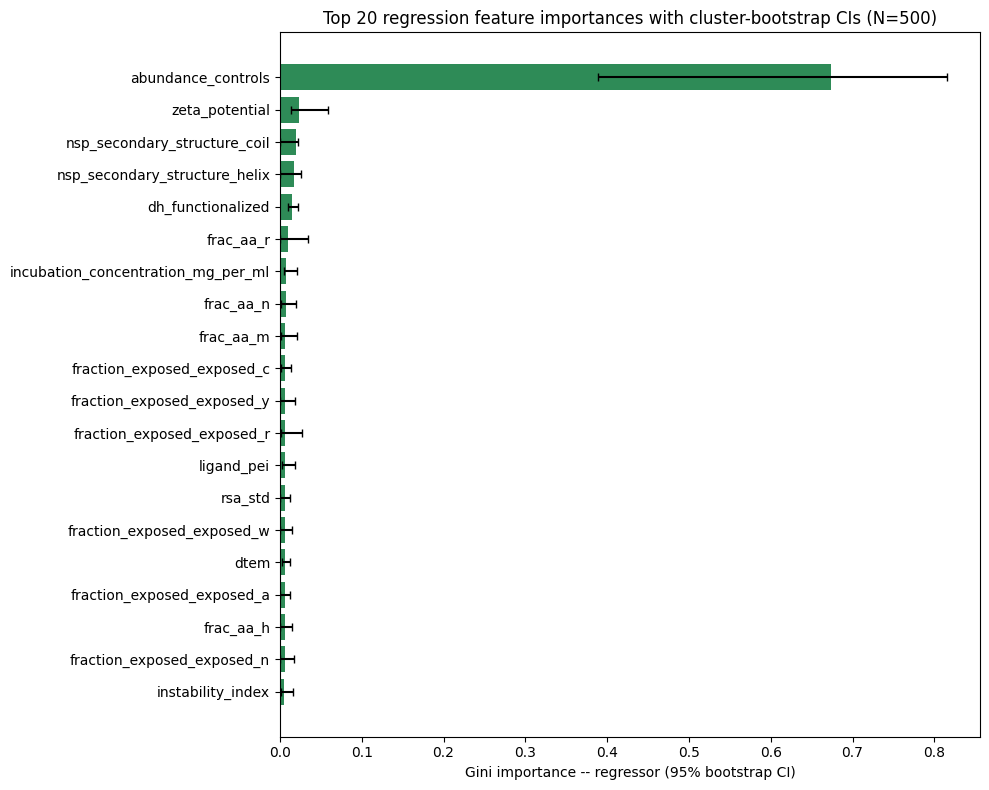

In [9]:
# Top-K regression importances with 95% bootstrap CI as error bars.
plot_topk_importance(
    importance_summary_reg,
    color="seagreen",
    xlabel="Gini importance -- regressor (95% bootstrap CI)",
    title=f"Top {TOP_K} regression feature importances with cluster-bootstrap CIs (N={N_BOOT})",
)

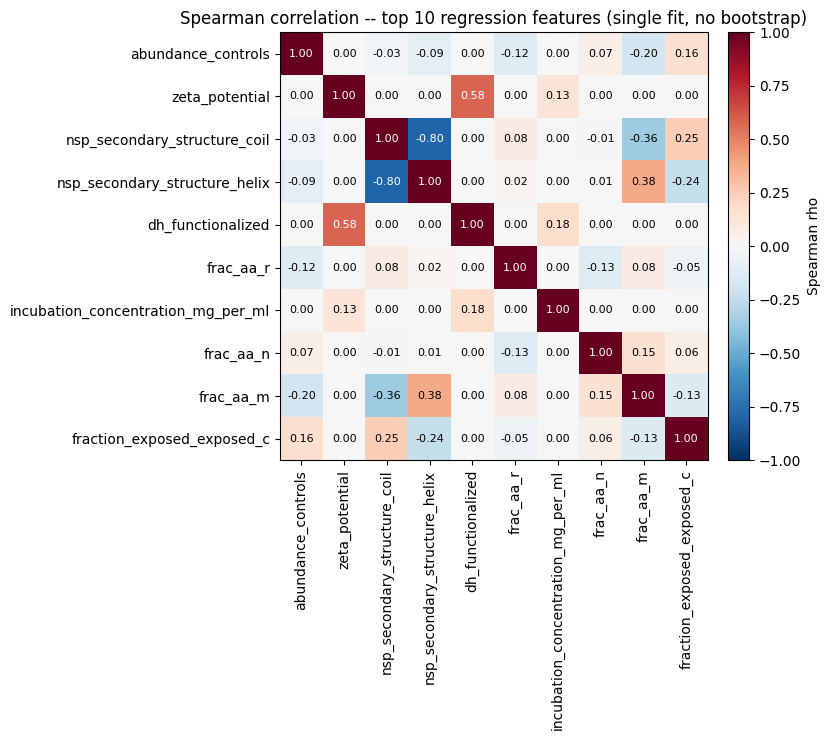

,abundance_controls,zeta_potential,nsp_secondary_structure_coil,nsp_secondary_structure_helix,dh_functionalized,frac_aa_r,incubation_concentration_mg_per_ml,frac_aa_n,frac_aa_m,fraction_exposed_exposed_c
abundance_controls,1.000,0.000,-0.026,-0.091,0.000,-0.125,0.000,0.069,-0.195,0.162
zeta_potential,0.000,1.000,0.000,0.000,0.581,0.000,0.132,0.000,0.000,0.000
nsp_secondary_structure_coil,-0.026,0.000,1.000,-0.803,0.000,0.085,0.000,-0.009,-0.359,0.246
nsp_secondary_structure_helix,-0.091,0.000,-0.803,1.000,0.000,0.020,0.000,0.008,0.377,-0.237
dh_functionalized,0.000,0.581,0.000,0.000,1.000,0.000,0.176,0.000,0.000,0.000
frac_aa_r,-0.125,0.000,0.085,0.020,0.000,1.000,0.000,-0.131,0.083,-0.049
incubation_concentration_mg_per_ml,0.000,0.132,0.000,0.000,0.176,0.000,1.000,0.000,0.000,0.000
frac_aa_n,0.069,0.000,-0.009,0.008,0.000,-0.131,0.000,1.000,0.151,0.055
frac_aa_m,-0.195,0.000,-0.359,0.377,0.000,0.083,0.000,0.151,1.000,-0.135
fraction_exposed_exposed_c,0.162,0.000,0.246,-0.237,0.000,-0.049,0.000,0.055,-0.135,1.000


In [10]:
# Spearman correlation among the top 10 features by single-fit regressor Gini importance.
top10_reg_feats = observed_importance_reg.head(10).index.tolist()
corr_reg = x[top10_reg_feats].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(corr_reg.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(top10_reg_feats)))
ax.set_xticklabels(top10_reg_feats, rotation=90)
ax.set_yticks(range(len(top10_reg_feats)))
ax.set_yticklabels(top10_reg_feats)
for i in range(len(top10_reg_feats)):
    for j in range(len(top10_reg_feats)):
        v = corr_reg.values[i, j]
        ax.text(
            j,
            i,
            f"{v:.2f}",
            ha="center",
            va="center",
            color="white" if abs(v) > 0.5 else "black",
            fontsize=8,
        )
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman rho")
ax.set_title(
    "Spearman correlation -- top 10 regression features (single fit, no bootstrap)"
)
plt.tight_layout()
plt.show()
corr_reg.round(3)

## RFC. Bootstrap Feature Importance

Cluster-bootstrap (N=500) Gini importances for the enrichment classifier on the full
feature set, with 95% percentile CIs.

In [11]:
# Baseline: single RF fit on full data to get observed Gini importances.
rfc_full = RandomForestClassifier(**rf_kwargs).fit(x, y)
observed_importance = pd.Series(
    rfc_full.feature_importances_, index=feature_columns, name="importance"
).sort_values(ascending=False)

observed_importance.head(20).to_frame()

,importance
zeta_potential,0.047076
abundance_controls,0.029204
dh_functionalized,0.025261
secondary_structure_fraction_sheet,0.023959
ligand_pei,0.023577
dtem,0.017426
frac_aa_a,0.015359
fraction_exposed,0.015216
nsp_secondary_structure_helix,0.015149
frac_aa_c,0.014838


In [12]:
# Cluster bootstrap by protein for the classifier (resample groups, refit, collect Gini).
boot_imp_df = cluster_bootstrap_importances(
    lambda s: RandomForestClassifier(**{**rf_kwargs, "random_state": s}),
    y.values,
    require_two_classes=True,
)
importance_summary_clf = build_importance_summary(observed_importance, boot_imp_df)
importance_summary_clf.head(20)

  bootstrap 100/500


  bootstrap 200/500


  bootstrap 300/500


  bootstrap 400/500


  bootstrap 500/500


,observed,boot_mean,ci_low,ci_high
zeta_potential,0.047076,0.060530,0.052501,0.068012
abundance_controls,0.029204,0.020766,0.008532,0.037825
dh_functionalized,0.025261,0.034230,0.029482,0.038765
secondary_structure_fraction_sheet,0.023959,0.019962,0.010317,0.032694
ligand_pei,0.023577,0.032976,0.026917,0.039062
dtem,0.017426,0.022291,0.018826,0.026222
frac_aa_a,0.015359,0.015678,0.008761,0.028115
fraction_exposed,0.015216,0.011767,0.007588,0.018623
nsp_secondary_structure_helix,0.015149,0.012868,0.008362,0.020656
frac_aa_c,0.014838,0.012484,0.007710,0.020867


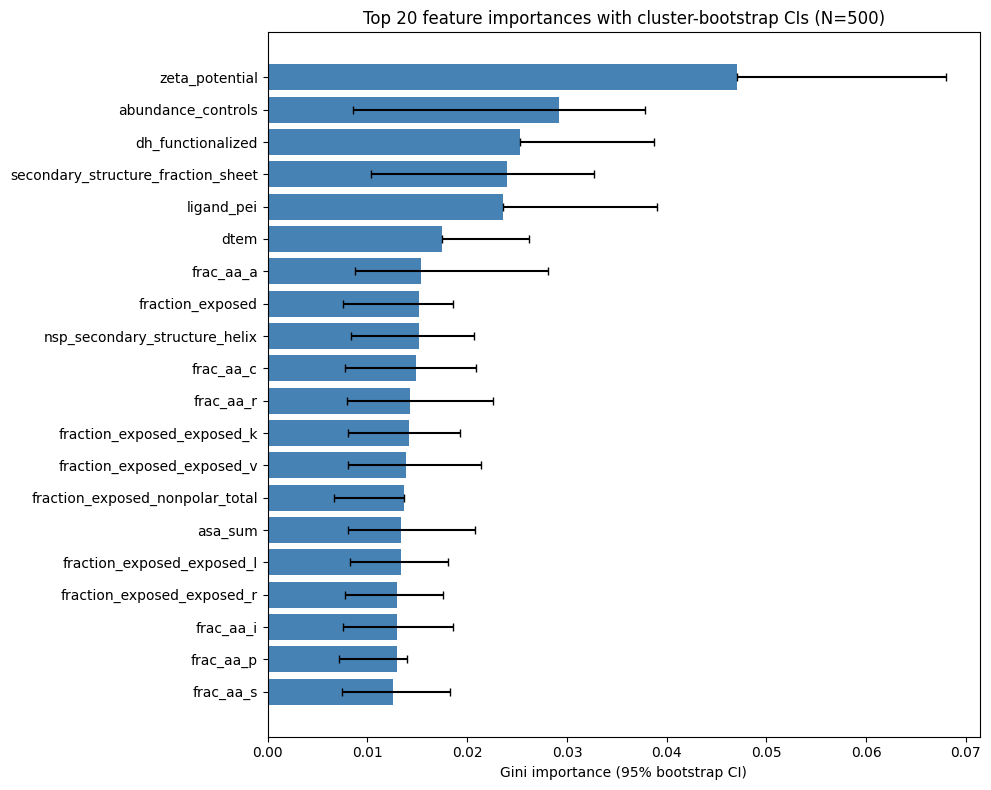

In [13]:
# Top-K classifier importances with 95% bootstrap CI as error bars.
plot_topk_importance(
    importance_summary_clf,
    color="steelblue",
    xlabel="Gini importance (95% bootstrap CI)",
    title=f"Top {TOP_K} feature importances with cluster-bootstrap CIs (N={N_BOOT})",
)

## SHAP Beeswarm. Regression on Full Data

TreeSHAP for the RF regressor refit on the full dataset under each of the three abundance
transforms. Beeswarm of the top-20 features per transform.

In [14]:
# Fit RF on the entire dataset under each transform.
rf_full_by_t = {}
for t_name, (fwd, _inv) in loo_transforms.items():
    y_full = fwd(df["abundance"].values)
    rf = RandomForestRegressor(**rf_kwargs).fit(df[feature_columns], y_full)
    rf_full_by_t[t_name] = rf
    print(f"{t_name:>11s}: in-sample R^2 = {rf.score(df[feature_columns], y_full):.4f}")

      log1p: in-sample R^2 = 0.8984


      asinh: in-sample R^2 = 0.8945


 log2_floor: in-sample R^2 = 0.8781


In [15]:
# TreeSHAP values for each transform's RF.
x_full = df[feature_columns]
shap_exp_by_t = {}
for t_name, rf in rf_full_by_t.items():
    expl = shap.TreeExplainer(rf)
    shap_exp_by_t[t_name] = expl(x_full, check_additivity=False)
    base = float(np.ravel(expl.expected_value)[0])
    print(
        f"{t_name:>11s}: SHAP shape {shap_exp_by_t[t_name].values.shape}, base = {base:.4f}"
    )

      log1p: SHAP shape (6768, 84), base = 0.0947


      asinh: SHAP shape (6768, 84), base = 0.1163


 log2_floor: SHAP shape (6768, 84), base = -9.0140


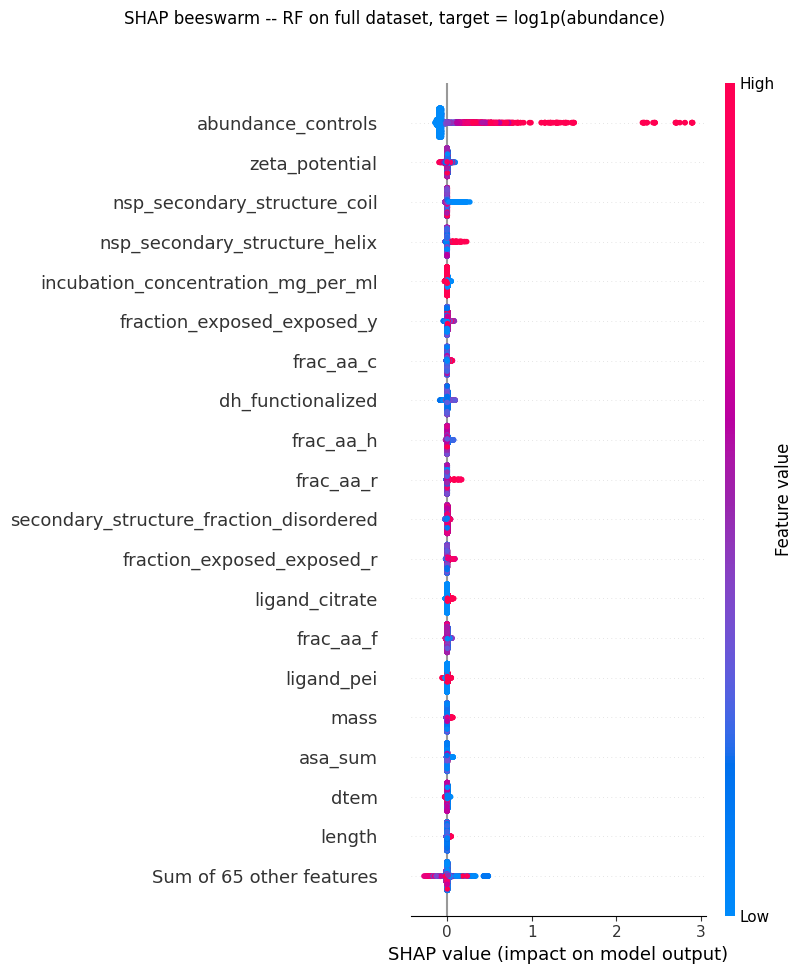

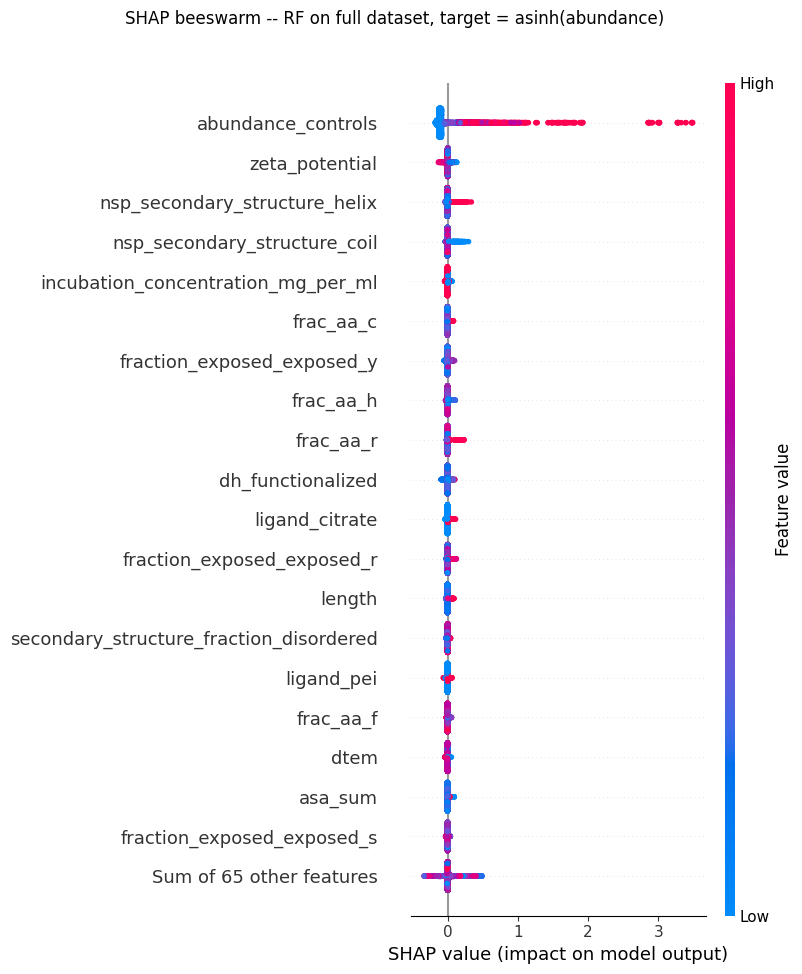

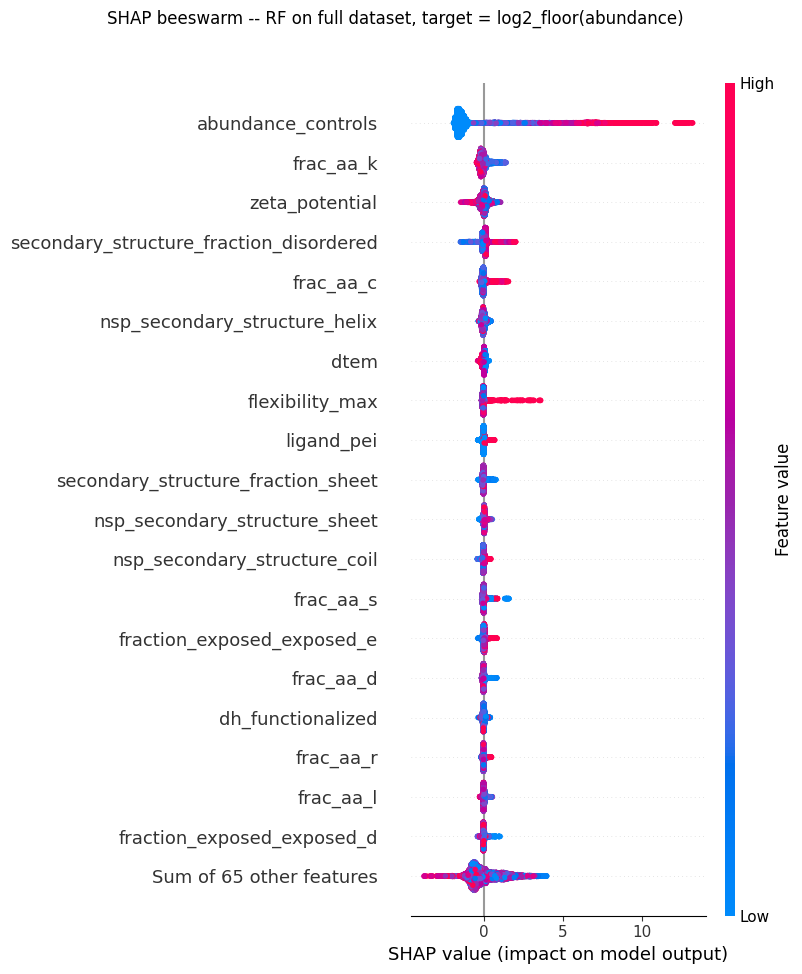

In [16]:
# Beeswarm per transform: top 20 features by mean |SHAP|.
for t_name, shap_exp in shap_exp_by_t.items():
    shap.plots.beeswarm(shap_exp, max_display=20, show=False)
    fig = plt.gcf()
    fig.suptitle(
        f"SHAP beeswarm -- RF on full dataset, target = {t_name}(abundance)", y=1.02
    )
    plt.tight_layout()
    plt.show()

## RFECV. Abundance Regressor

Recursive feature elimination with GroupKFold-5 by NP, scoring negative MAE in `log1p`
space. Marks the min-MAE K and the 1-SD parsimonious K.

reg RFECV selected K: 77 / 84
min-MAE K:            77  (CV MAE 0.0482 +/- 0.0080, log1p space)
1-SD parsimonious K:  3  (CV MAE 0.0561)
full-set CV MAE:      0.0484 +/- 0.0081


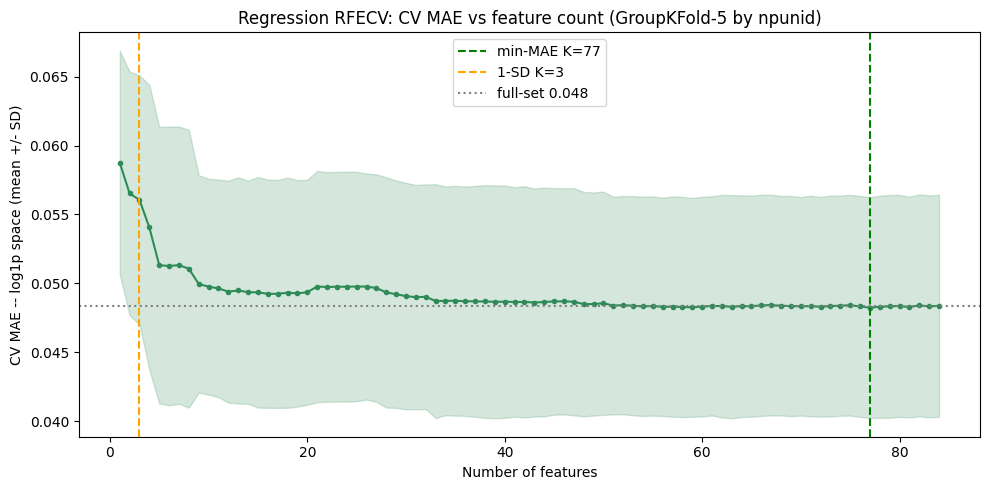


Regression-selected parsimonious features:
  abundance_controls
  zeta_potential
  nsp_secondary_structure_coil


In [17]:
# RFECV feature selection; folds grouped by NP via groups=groups_loo (npunid).
# scoring = neg MAE in log1p space (y_reg_full).
# NOTE: this SELECTION step uses 5 grouped folds (GroupKFold-5), NOT leave-one-NP-out.
rfecv_reg = RFECV(
    estimator=RandomForestRegressor(**rf_kwargs),
    step=1,
    cv=GroupKFold(n_splits=5),
    scoring="neg_mean_absolute_error",
    min_features_to_select=1,
    n_jobs=-1,
)
rfecv_reg.fit(df[feature_columns].values, y_reg_full, groups=groups_loo)

# reg_scores are negative MAE (higher = better).
reg_scores, reg_stds, reg_best_k, reg_parsi_k = rfecv_ks(rfecv_reg)

reg_rank = pd.Series(rfecv_reg.ranking_, index=feature_columns)
reg_selected_features = reg_rank[reg_rank == 1].index.tolist()
# parsimonious set: among the kept features, the top reg_parsi_k by the
# fitted RFECV estimator's importances.
reg_imp = pd.Series(
    rfecv_reg.estimator_.feature_importances_, index=reg_selected_features
)
reg_parsimonious_features = (
    reg_imp.sort_values(ascending=False).index[:reg_parsi_k].tolist()
)

print(f"reg RFECV selected K: {len(reg_selected_features)} / {len(feature_columns)}")
print(
    f"min-MAE K:            {reg_best_k}  "
    f"(CV MAE {-reg_scores[reg_best_k - 1]:.4f} +/- {reg_stds[reg_best_k - 1]:.4f}, log1p space)"
)
print(
    f"1-SD parsimonious K:  {reg_parsi_k}  (CV MAE {-reg_scores[reg_parsi_k - 1]:.4f})"
)
print(f"full-set CV MAE:      {-reg_scores[-1]:.4f} +/- {reg_stds[-1]:.4f}")

plot_rfecv_curve(
    -reg_scores,
    reg_stds,
    reg_best_k,
    reg_parsi_k,
    color="seagreen",
    best_label="min-MAE",
    ylabel="CV MAE -- log1p space (mean +/- SD)",
    title="Regression RFECV: CV MAE vs feature count (GroupKFold-5 by npunid)",
)

print("\nRegression-selected parsimonious features:")
for f in reg_parsimonious_features:
    print(" ", f)

**CV-grouping note (NP vs protein).** This RFECV groups folds by NP (`npunid`), matching the leave-one-NP-out evaluation further below. Re-running it grouped by protein (`entry`) changes the result substantially: min-MAE rises from ~0.048 to ~0.088 (log1p) and the survivor set collapses from 77 to 7 features (those 7 are a subset of the 77).

## Permutation Importance (OOF). Classifier

Out-of-fold permutation importance (GroupKFold by protein, ROC AUC) for the enrichment
classifier. Used to order the RFECV-selected features below.

In [18]:
# Out-of-fold permutation importance (corona.py): per GroupKFold-by-protein fold, fit on
# train, then shuffle each column on the test set and measure the drop in ROC AUC.
# Rows = folds x repeats.
perm_obs_imp = oof_permutation_importance(
    RandomForestClassifier, x, y, groups, "roc_auc", n_folds=N_FOLDS, n_repeats=N_REPEATS
)
perm_obs_imp.shape

  fold 1/10


  fold 2/10


  fold 3/10


  fold 4/10


  fold 5/10


...

  fold 7/10


  fold 8/10


  fold 9/10


  fold 10/10


(100, 84)

In [19]:
# Rank features by mean permutation importance with 95% CI (across folds x repeats)
perm_summary = pd.DataFrame(
    {
        "mean": perm_obs_imp.mean(),
        "std": perm_obs_imp.std(),
        "ci_low": perm_obs_imp.quantile(0.025),
        "ci_high": perm_obs_imp.quantile(0.975),
    }
).sort_values("mean", ascending=False)
perm_summary.head(20)

,mean,std,ci_low,ci_high
abundance_controls,0.020325,0.021942,-0.026879,0.059574
secondary_structure_fraction_sheet,0.018602,0.013412,0.000068,0.050434
zeta_potential,0.016832,0.009143,-0.000713,0.031602
ligand_pei,0.010875,0.006177,-0.000341,0.025221
nsp_secondary_structure_coil,0.008409,0.007646,-0.004557,0.024298
fraction_exposed_exposed_k,0.007823,0.008030,-0.010678,0.020358
frac_aa_a,0.005911,0.010554,-0.008041,0.031108
frac_aa_c,0.005665,0.005571,-0.002015,0.018461
dtem,0.005287,0.003092,-0.001018,0.010311
frac_aa_r,0.005214,0.010479,-0.009933,0.032097


## RFECV. Enrichment classifier (7-feature parsimonious set)

Recursive feature elimination with GroupKFold by protein, scoring ROC AUC. The 1-SD
parsimonious criterion selects 7 features (= `PARSI_7`). Ties among RFECV survivors are
broken by permutation-importance rank.

In [20]:
# RFECV feature selection; cv=gkf is GroupKFold(n_splits=10), folds grouped by
# protein via groups=groups (entry) passed to .fit(). step=1 drops one feature per round.
# (Contrast the regressor RFECV above, which groups by NP. See the CV-grouping note.)
rfecv = RFECV(
    estimator=RandomForestClassifier(**rf_kwargs),
    step=1,
    cv=gkf,
    scoring="roc_auc",
    min_features_to_select=1,
    n_jobs=-1,
)
rfecv.fit(x, y, groups=groups)

scores, stds, best_k, parsimonious_k = rfecv_ks(rfecv)

print(f"RFECV selected K:    {rfecv.n_features_} / {x.shape[1]}")
print(
    f"max-AUC K:           {best_k}   (CV AUC {scores[best_k - 1]:.4f} +/- {stds[best_k - 1]:.4f})"
)
print(
    f"1-SD parsimonious K: {parsimonious_k}   (CV AUC {scores[parsimonious_k - 1]:.4f})"
)
print(f"full-set CV AUC:     {scores[-1]:.4f} +/- {stds[-1]:.4f}")

RFECV selected K:    26 / 84
max-AUC K:           26   (CV AUC 0.6975 +/- 0.0544)
1-SD parsimonious K: 7   (CV AUC 0.6448)
full-set CV AUC:     0.6811 +/- 0.0471


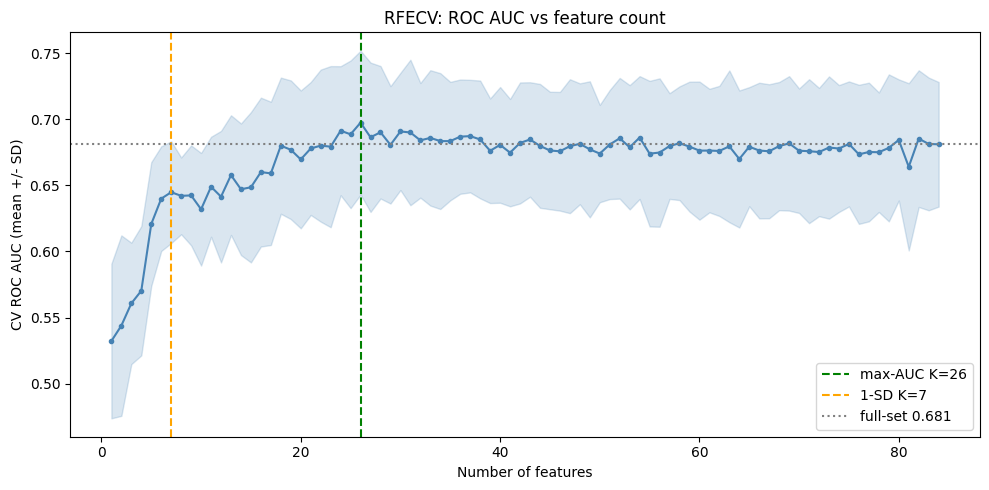

In [21]:
# CV ROC AUC vs feature count. Mark the max-AUC K, the 1-SD K, and the full-set baseline.
plot_rfecv_curve(
    scores,
    stds,
    best_k,
    parsimonious_k,
    color="steelblue",
    best_label="max-AUC",
    ylabel="CV ROC AUC (mean +/- SD)",
    title="RFECV: ROC AUC vs feature count",
)

In [22]:
# Selected features (RFECV survivors) with their permutation-importance rank for context.
# rfecv.ranking_: 1 = kept; higher numbers = eliminated (larger = eliminated earlier).
elim_rank = pd.Series(rfecv.ranking_, index=feature_columns, name="rfecv_rank")
perm_rank = pd.Series(
    np.arange(1, len(perm_summary) + 1), index=perm_summary.index, name="perm_rank"
)

selected_features = elim_rank[elim_rank == 1].index.tolist()
selected_df = pd.DataFrame(
    {
        "perm_rank": perm_rank.reindex(selected_features),
        "perm_mean": perm_summary["mean"].reindex(selected_features),
    }
).sort_values("perm_rank")
print(f"{len(selected_features)} features kept by RFECV (max-AUC criterion):")
selected_df

26 features kept by RFECV (max-AUC criterion):


,perm_rank,perm_mean
abundance_controls,1,0.020325
secondary_structure_fraction_sheet,2,0.018602
zeta_potential,3,0.016832
ligand_pei,4,0.010875
nsp_secondary_structure_coil,5,0.008409
fraction_exposed_exposed_k,6,0.007823
frac_aa_a,7,0.005911
frac_aa_c,8,0.005665
frac_aa_r,10,0.005214
dh_functionalized,11,0.005027


In [23]:
feature_order = pd.DataFrame(
    {
        "elim": elim_rank,
        "perm": perm_rank.reindex(elim_rank.index).fillna(len(perm_rank) + 1),
    }
).sort_values(["elim", "perm"])

parsimonious_features = feature_order.index[:parsimonious_k].tolist()
assert set(parsimonious_features) == set(PARSI_7), (
    "RFECV 1-SD parsimonious set != hardcoded PARSI_7\n"
    f"  RFECV:   {sorted(parsimonious_features)}\n"
    f"  PARSI_7: {sorted(PARSI_7)}"
)

metrics_df = pd.DataFrame(
    [
        {"set": "full", **oof_classifier_metrics(feature_columns)},
        {"set": "rfecv", **oof_classifier_metrics(selected_features)},
        {"set": "parsimonious", **oof_classifier_metrics(parsimonious_features)},
    ]
).set_index("set")
print(metrics_df.round(4))
print("\nParsimonious feature set:")
for f in parsimonious_features:
    print(" ", f)

               K  roc_auc  accuracy  balanced_accuracy  precision  recall  \
set                                                                         
full          84   0.6769    0.6556             0.5883     0.6350  0.2800   
rfecv         26   0.7131    0.6871             0.6305     0.6838  0.3711   
parsimonious   7   0.6743    0.6649             0.6164     0.6107  0.3942   

                  f1  
set                   
full          0.3887  
rfecv         0.4811  
parsimonious  0.4791  

Parsimonious feature set:
  abundance_controls
  secondary_structure_fraction_sheet
  zeta_potential
  ligand_pei
  nsp_secondary_structure_coil
  fraction_exposed_exposed_k
  frac_aa_a


**CV-grouping note (protein vs NP).** This RFECV groups folds by protein (`entry`). Re-running it grouped by NP (`npunid`) instead inflates CV ROC AUC from ~0.70 to ~0.86 and shrinks the survivor set from 26 to 9 features (dropping 3 of the 7 `PARSI_7` features). That jump is leakage. Leaving protein-based grouping.

## Parsimonious Model. 6 Features

Enrichment classifier and abundance regressor on `PARSI_6`, each with PDP/ICE and SHAP,
followed by protein response-curve clustering. The 7-feature set is kept as a reference to
confirm dropping the collinear `ligand_pei` costs nothing.

In [24]:
# Collinearity of the dropped feature, and the 6-feature correlation structure.
rho, p = spearmanr(x["zeta_potential"], x["ligand_pei"])
print(f"Spearman(zeta_potential, ligand_pei) = {rho:.3f}  (p={p:.2e})")
print("\n6-feature parsimonious set:")
for f in PARSI_6:
    print(" ", f)

corr6 = x[PARSI_6].corr(method="spearman")
print("\nSpearman correlation among the 6 features:")
corr6.round(3)

Spearman(zeta_potential, ligand_pei) = 0.821  (p=0.00e+00)

6-feature parsimonious set:
  abundance_controls
  secondary_structure_fraction_sheet
  zeta_potential
  nsp_secondary_structure_coil
  fraction_exposed_exposed_k
  frac_aa_a

Spearman correlation among the 6 features:


,abundance_controls,secondary_structure_fraction_sheet,zeta_potential,nsp_secondary_structure_coil,fraction_exposed_exposed_k,frac_aa_a
abundance_controls,1.000,-0.018,0.0,-0.026,-0.063,-0.052
secondary_structure_fraction_sheet,-0.018,1.000,0.0,-0.484,0.155,0.594
zeta_potential,0.000,0.000,1.0,0.000,0.000,0.000
nsp_secondary_structure_coil,-0.026,-0.484,0.0,1.000,-0.428,-0.313
fraction_exposed_exposed_k,-0.063,0.155,0.0,-0.428,1.000,-0.035
frac_aa_a,-0.052,0.594,0.0,-0.313,-0.035,1.000


### Enrichment / Depletion Classifier

In [25]:
# Out-of-fold metrics via the shared helper; keep predictions for the 6-feature model.
m_full = oof_classifier_metrics(feature_columns)
m7 = oof_classifier_metrics(PARSI_7)
proba6, pred6, m6 = oof_classifier_metrics(PARSI_6, return_preds=True)

clf_metrics = pd.DataFrame(
    [{"set": "full_84", **m_full}, {"set": "parsi_7", **m7}, {"set": "parsi_6", **m6}]
).set_index("set")
print(clf_metrics.round(4))

          K  roc_auc  accuracy  balanced_accuracy  precision  recall      f1
set                                                                         
full_84  84   0.6769    0.6556             0.5883     0.6350  0.2800  0.3887
parsi_7   7   0.6743    0.6649             0.6164     0.6107  0.3942  0.4791
parsi_6   6   0.6683    0.6597             0.6119     0.5988  0.3927  0.4743


Classification report -- 6-feature model (out-of-fold):
              precision    recall  f1-score   support

    depleted      0.681     0.831     0.748      4122
    enriched      0.599     0.393     0.474      2646

    accuracy                          0.660      6768
   macro avg      0.640     0.612     0.611      6768
weighted avg      0.649     0.660     0.641      6768



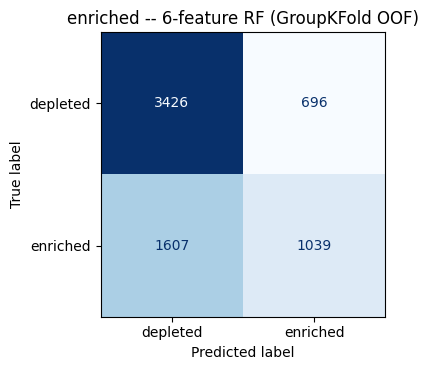

In [26]:
print("Classification report -- 6-feature model (out-of-fold):")
print(classification_report(y, pred6, digits=3, target_names=["depleted", "enriched"]))

cm = confusion_matrix(y, pred6)
fig, ax = plt.subplots(figsize=(4.2, 3.8))
ConfusionMatrixDisplay(cm, display_labels=["depleted", "enriched"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("enriched -- 6-feature RF (GroupKFold OOF)")
plt.tight_layout()
plt.show()

### PDP + ICE. Classifier

Classifier refit on all rows with the 6 features. Each panel shows the blue PDP (average
effect) over a thin ICE sample; y axis is partial dependence of P(enriched).

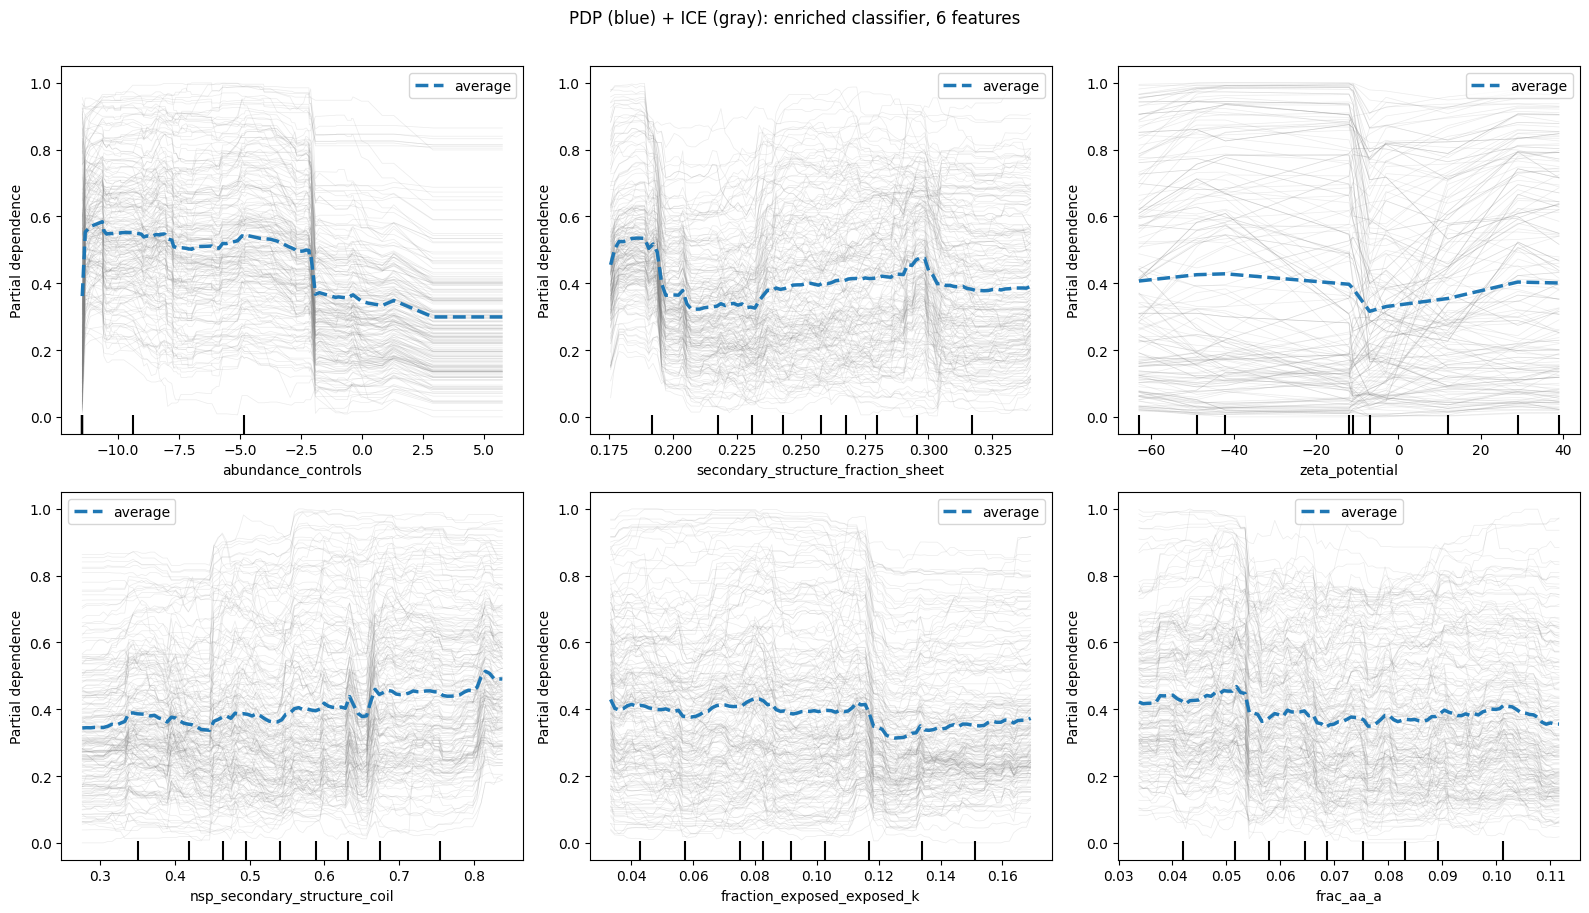

In [27]:
x6 = x[PARSI_6].astype(float)
clf_full = RandomForestClassifier(**rf_kwargs).fit(x6, y)

plot_pdp_ice(
    clf_full,
    x6,
    PARSI_6,
    pd_color="tab:blue",
    title="PDP (blue) + ICE (gray): enriched classifier, 6 features",
)

### SHAP. Classifier

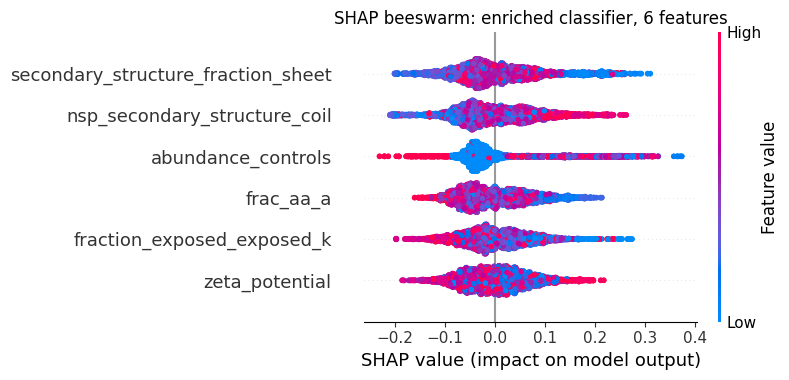

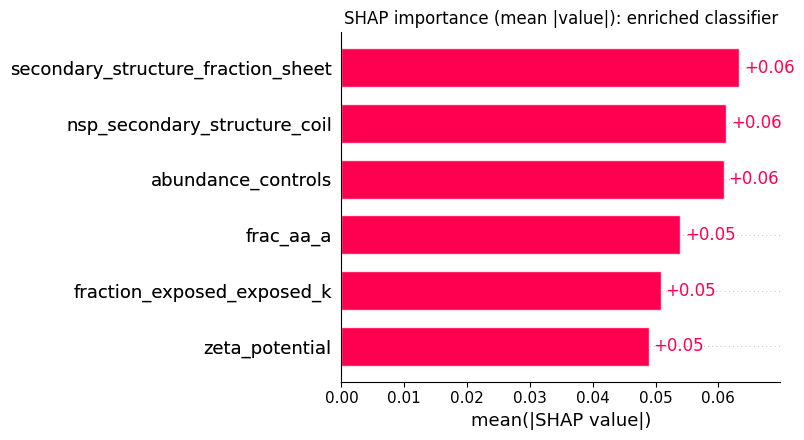

In [28]:
# TreeExplainer is exact and fast for random forests; clf_full was fit above on x6.
sv_clf = shap.TreeExplainer(clf_full)(x6)
# Binary classifier: SHAP values come per class, keep the "enriched" class.
sv_clf_pos = sv_clf[..., 1]

shap.plots.beeswarm(sv_clf_pos, show=False)
plt.title("SHAP beeswarm: enriched classifier, 6 features")
plt.tight_layout()
plt.show()

shap.plots.bar(sv_clf_pos, show=False)
plt.title("SHAP importance (mean |value|): enriched classifier")
plt.tight_layout()
plt.show()

### Abundance Regressor: 3 Transforms

True leave-one-NP-out (18 folds). Metrics reported both in the transformed target space
(`*_t`) and back in raw abundance space (`*_raw`).

In [29]:
def loo_regression(features, name):
    """True leave-one-NP-out RF regression across the 3 abundance transforms."""
    x_loo = df[features].values
    recs = []
    for t_name, (fwd, inv) in loo_transforms.items():
        y_t = fwd(y_loo_raw)
        pred_t, true_t, pred_raw, true_raw = [], [], [], []
        for np_id in unique_nps_loo:
            train = groups_loo != np_id
            test = groups_loo == np_id
            rf = RandomForestRegressor(**rf_kwargs).fit(x_loo[train], y_t[train])
            p = rf.predict(x_loo[test])
            pred_t.append(p)
            true_t.append(y_t[test])
            pred_raw.append(inv(p))
            true_raw.append(y_loo_raw[test])
        pred_t, true_t = np.concatenate(pred_t), np.concatenate(true_t)
        pred_raw, true_raw = np.concatenate(pred_raw), np.concatenate(true_raw)
        recs.append(
            {
                "set": name,
                "K": len(features),
                "transform": t_name,
                "r2_t": r2_score(true_t, pred_t),
                "mae_t": mean_absolute_error(true_t, pred_t),
                "r2_raw": r2_score(true_raw, pred_raw),
                "mae_raw": mean_absolute_error(true_raw, pred_raw),
                "rmse_raw": root_mean_squared_error(true_raw, pred_raw),
                "spearman_raw": spearmanr(true_raw, pred_raw).statistic,
            }
        )
    return pd.DataFrame(recs)


reg_metrics = pd.concat(
    [
        loo_regression(feature_columns, "full_84"),
        loo_regression(PARSI_7, "parsi_7"),
        loo_regression(PARSI_6, "parsi_6"),
    ],
    ignore_index=True,
)
reg_metrics.set_index(["set", "transform"]).round(4)

K    r2_t   mae_t  r2_raw  mae_raw  rmse_raw  \
set     transform                                                   
full_84 log1p       84  0.8305  0.0447  0.8091   0.1280    0.8564   
        asinh       84  0.8245  0.0557  0.8083   0.1287    0.8583   
        log2_floor  84  0.7810  1.4666  0.7962   0.1257    0.8849   
parsi_7 log1p        7  0.8281  0.0453  0.7890   0.1350    0.9004   
        asinh        7  0.8223  0.0565  0.7877   0.1358    0.9032   
        log2_floor   7  0.7727  1.4643  0.7782   0.1322    0.9232   
parsi_6 log1p        6  0.8280  0.0453  0.7889   0.1350    0.9006   
        asinh        6  0.8222  0.0565  0.7877   0.1358    0.9033   
        log2_floor   6  0.7727  1.4646  0.7781   0.1322    0.9235   

                    spearman_raw  
set     transform                 
full_84 log1p             0.7415  
        asinh             0.7360  
        log2_floor        0.7913  
parsi_7 log1p             0.7470  
        asinh             0.7447  
        log2_floor        0.7870  
parsi_6 log1p             0.7470  
        asinh             0.7447  
        log2_floor        0.7869

### PDP + ICE. Regression

One PDP/ICE grid per transform, regressor refit on all rows. Y axis is partial dependence
of the predicted target in transformed space.

In [30]:
# Refit the 6-feature regressor once per transform; reused by PDP/ICE and SHAP below.
x6_reg = df[PARSI_6].astype(float)
reg6_fit_by_t = {
    t_name: RandomForestRegressor(**rf_kwargs).fit(x6_reg, fwd(y_loo_raw))
    for t_name, (fwd, _inv) in loo_transforms.items()
}

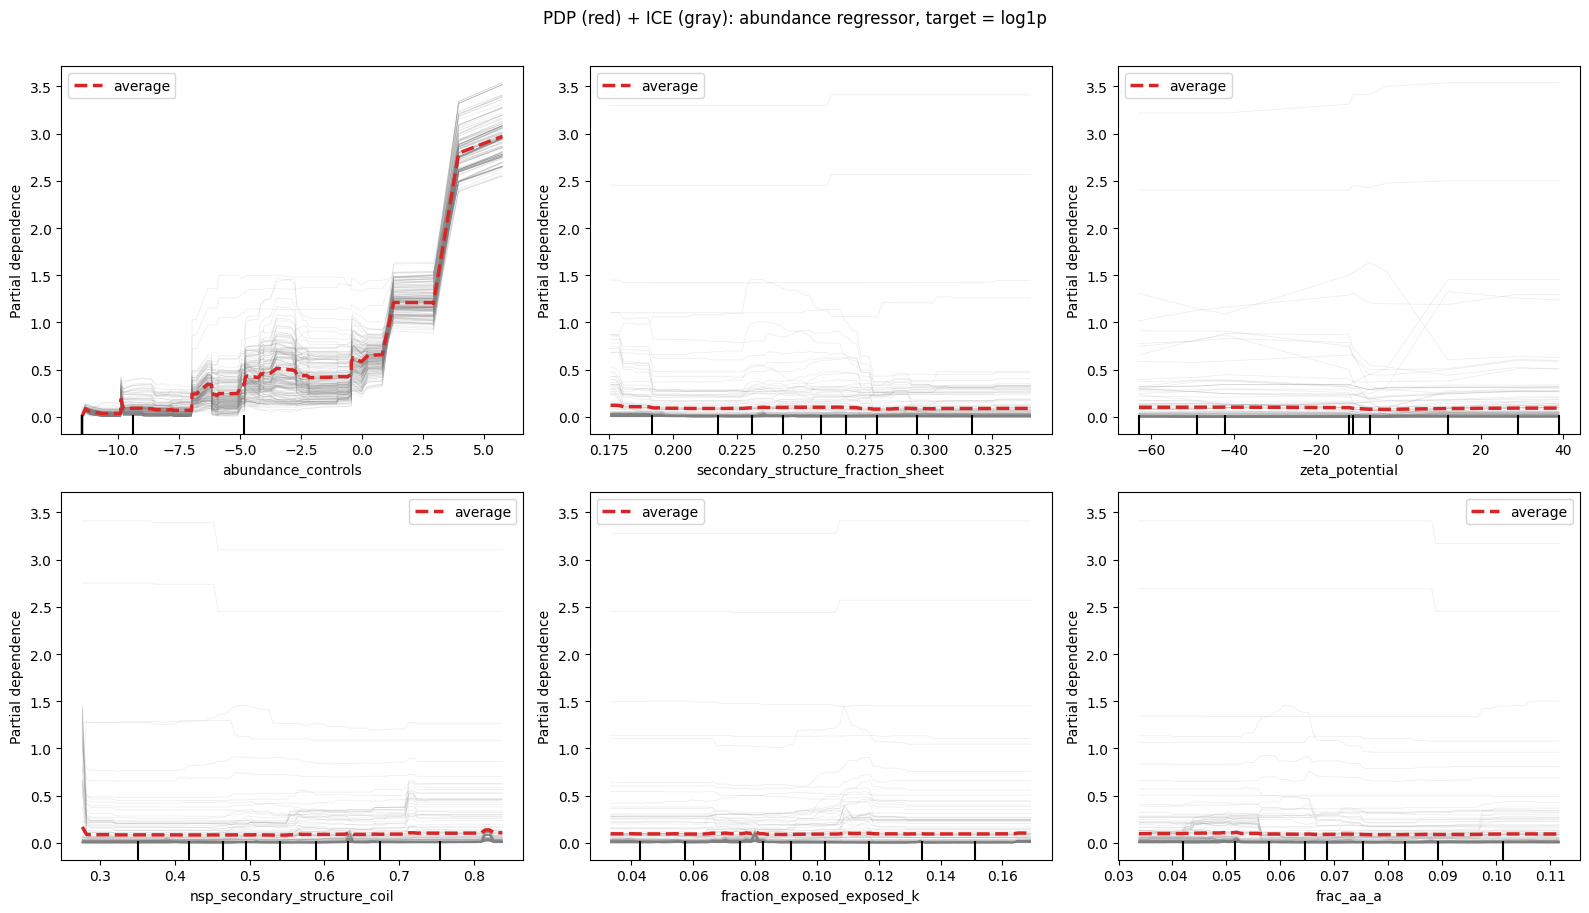

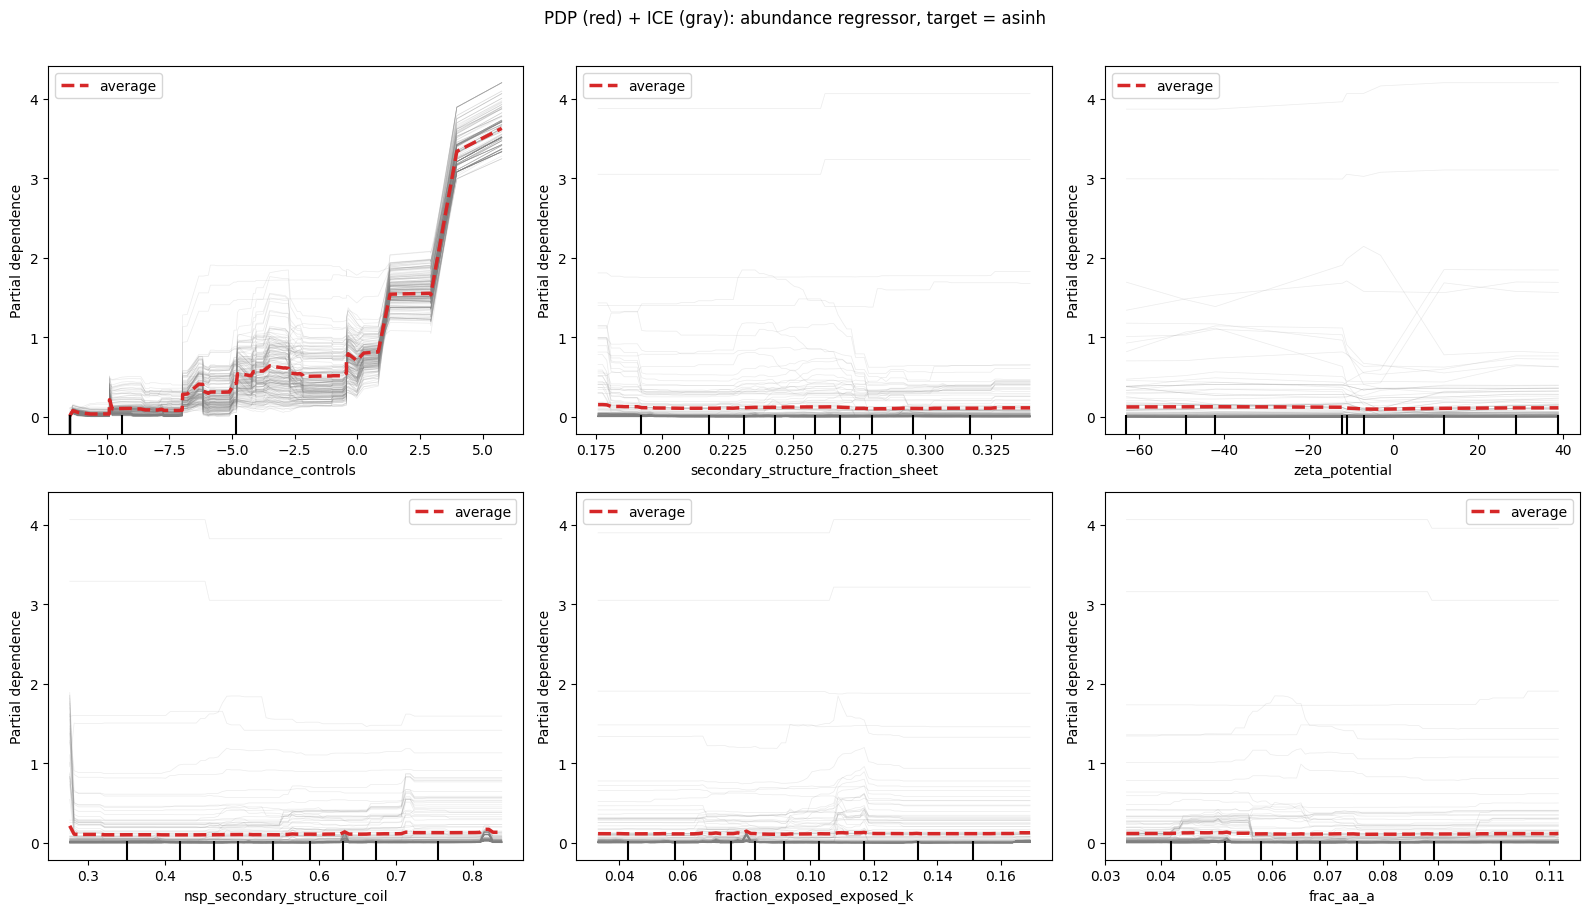

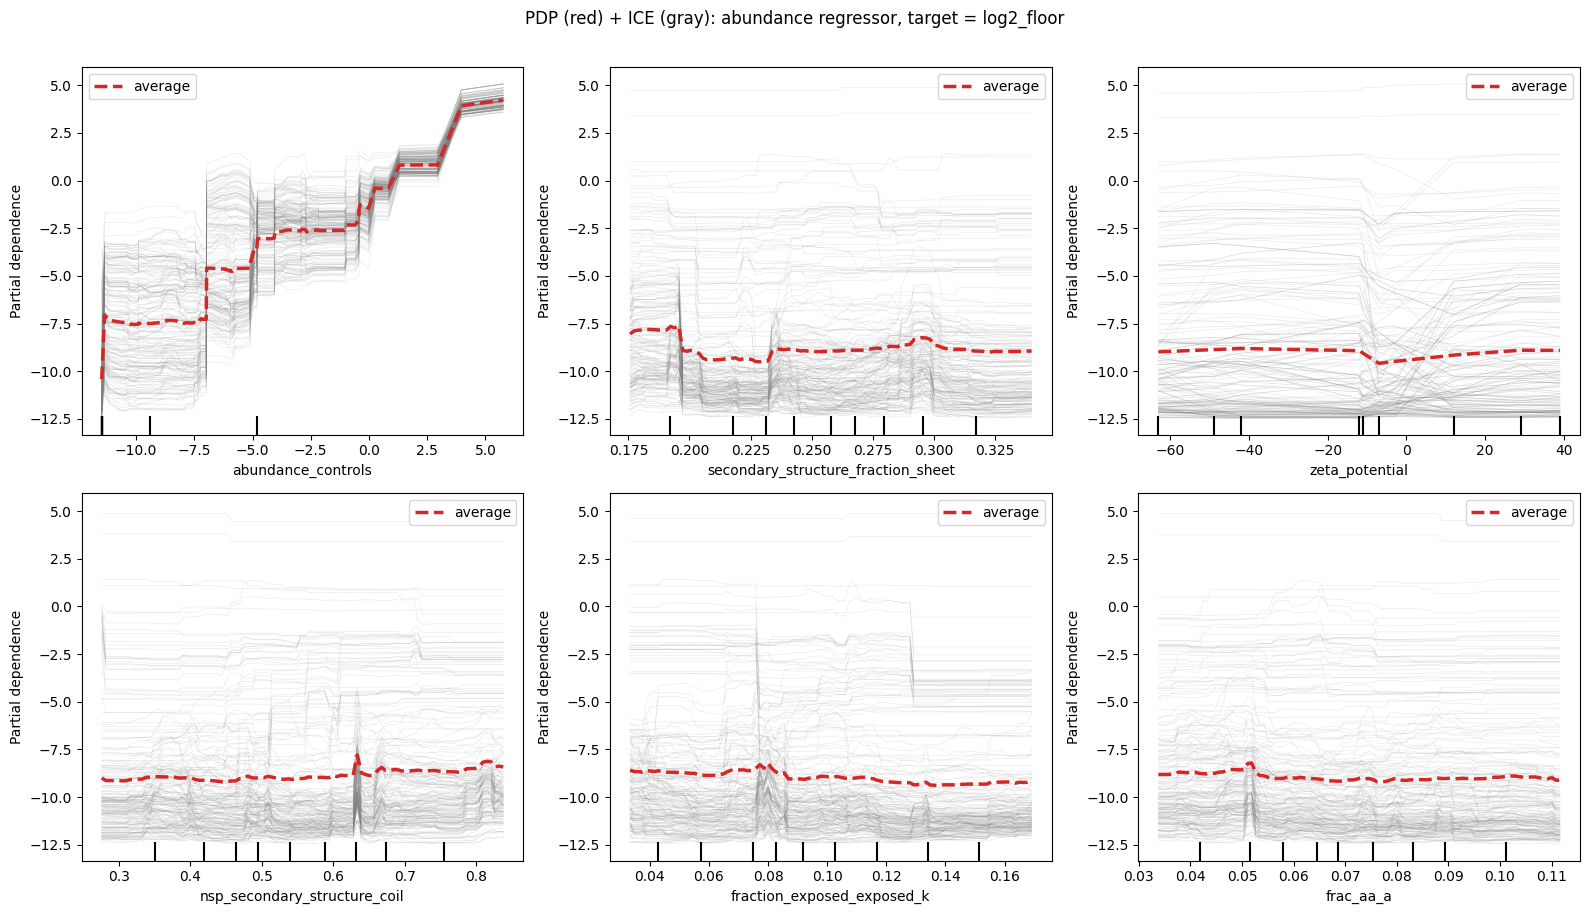

In [31]:
for t_name, reg_fit in reg6_fit_by_t.items():
    plot_pdp_ice(
        reg_fit,
        x6_reg,
        PARSI_6,
        pd_color="tab:red",
        title=f"PDP (red) + ICE (gray): abundance regressor, target = {t_name}",
    )

### SHAP. Regression

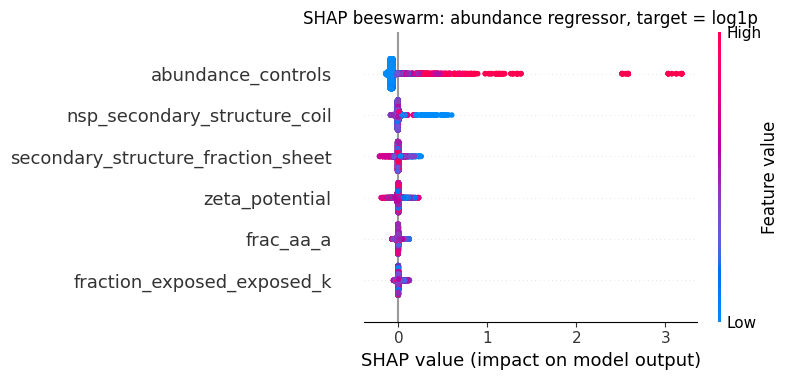

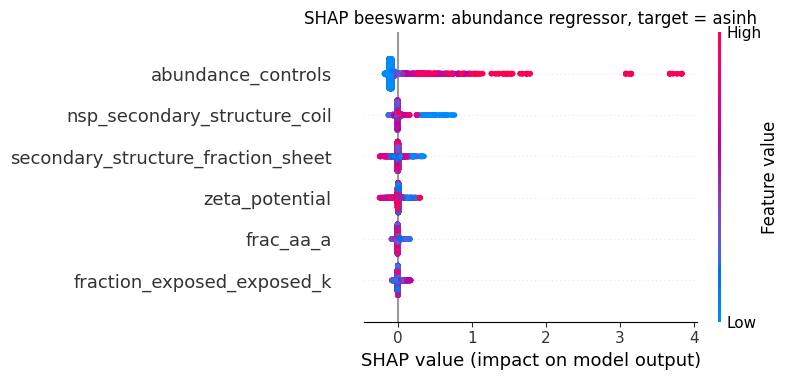

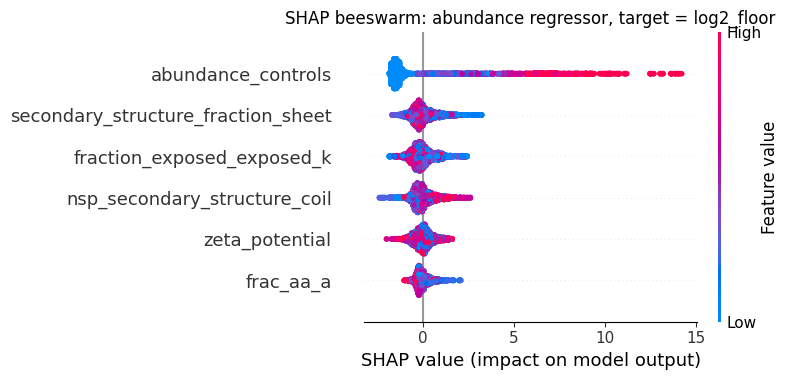

In [32]:
sv_reg6_by_t = {}
for t_name, reg_fit in reg6_fit_by_t.items():
    sv_reg = shap.TreeExplainer(reg_fit)(x6_reg)
    sv_reg6_by_t[t_name] = sv_reg
    shap.plots.beeswarm(sv_reg, show=False)
    plt.title(f"SHAP beeswarm: abundance regressor, target = {t_name}")
    plt.tight_layout()
    plt.show()

### Protein Clustering. Detection vs Enrichment Response

Per protein, sweep `zeta_potential` over {-60,-40,-20,0,20,40} and record P(class=1),
giving a 376x6 response matrix. K-means (k=3) clusters proteins by response-curve shape,
for both a detection classifier (`abundance > 0`) and the enrichment classifier. Labels
are reordered 0->2 by ascending mean response probability so the two are comparable.

In [33]:
# `response_matrices` (corona.py) fits the detection (abundance > 0) and enrichment
# classifiers on PARSI_6 and sweeps ZETA_GRID per protein, holding the other features at
# that protein's first-row values. The enrichment fit is the same as clf_full above.
protein_ids, resp_detect, resp_enrich = response_matrices(df)
print(f"response matrices: detect {resp_detect.shape}, enrich {resp_enrich.shape}")

response matrices: detect (376, 6), enrich (376, 6)


In [34]:
# `cluster_response` (corona.py): k-means (k=3) with clusters relabelled 0->2 by ascending
# mean response probability, so the detection and enrichment partitions are comparable.
def cluster_summary(resp, labels, name):
    s = pd.DataFrame(
        {
            "cluster": labels,
            "mean_prob": resp.mean(axis=1),
            "zeta_sensitivity": resp.max(axis=1) - resp.min(axis=1),
        }
    )
    out = (
        s.groupby("cluster")
        .agg(
            n=("cluster", "size"),
            mean_prob=("mean_prob", "mean"),
            zeta_sensitivity=("zeta_sensitivity", "mean"),
        )
        .round(3)
    )
    out.index.name = f"{name}_cluster"
    return out


cl_detect = cluster_response(resp_detect)
cl_enrich = cluster_response(resp_enrich)

detect_summary = cluster_summary(resp_detect, cl_detect, "detect")
enrich_summary = cluster_summary(resp_enrich, cl_enrich, "enrich")
print("Detection clustering:")
print(detect_summary)
print("\nEnrichment clustering:")
print(enrich_summary)

Detection clustering:
                  n  mean_prob  zeta_sensitivity
detect_cluster                                  
0               198      0.211             0.322
1                80      0.537             0.467
2                98      0.917             0.101

Enrichment clustering:
                  n  mean_prob  zeta_sensitivity
enrich_cluster                                  
0               218      0.194             0.292
1                73      0.468             0.490
2                85      0.807             0.251


In [35]:
clusters = pd.DataFrame(
    {
        "protein_id": protein_ids,
        "cluster_detect": cl_detect,
        "cluster_enrich": cl_enrich,
    }
)

ari = adjusted_rand_score(cl_detect, cl_enrich)
same = cl_detect == cl_enrich
print(f"Adjusted Rand index (detect vs enrich): {ari:.3f}")
print(
    f"Proteins with the same cluster label:   {same.mean():.1%}  "
    f"({same.sum()}/{len(clusters)})"
)

print("\nContingency table (rows = detection cluster, cols = enrichment cluster):")
pd.crosstab(
    clusters["cluster_detect"],
    clusters["cluster_enrich"],
    rownames=["detect"],
    colnames=["enrich"],
)

Adjusted Rand index (detect vs enrich): 0.655
Proteins with the same cluster label:   85.1%  (320/376)

Contingency table (rows = detection cluster, cols = enrichment cluster):


enrich,0,1,2
detect,,,
0,192,6,0
1,7,58,15
2,19,9,70


### What Protein Features Define Each Cluster

A protein's cluster is fully determined by its 5 non-zeta `PARSI_6` features. Per-cluster
means plus a Kruskal-Wallis test of whether each feature differs across the 3 clusters
(small `p_value` = the feature separates clusters), with boxplots of the distributions.

In [36]:
# The 5 non-zeta PARSI_6 features -- protein-level, so one value per protein.
PROTEIN_FEATS_6 = [f for f in PARSI_6 if f != "zeta_potential"]
protein_feat = df.groupby("entry")[PROTEIN_FEATS_6].first()
prof = clusters.join(protein_feat, on="protein_id")


def characterize(label_col):
    """Per-cluster feature means + Kruskal-Wallis test across the 3 clusters."""
    rows = []
    for feat in PROTEIN_FEATS_6:
        feat_groups = [g[feat].values for _, g in prof.groupby(label_col)]
        means = prof.groupby(label_col)[feat].mean()
        stat, p = kruskal(*feat_groups)
        rows.append(
            {
                "feature": feat,
                **{f"c{c}_mean": means[c] for c in means.index},
                "kruskal_H": stat,
                "p_value": p,
            }
        )
    return pd.DataFrame(rows).set_index("feature").round(4)


detect_profile = characterize("cluster_detect")
enrich_profile = characterize("cluster_enrich")
print("Detection clusters -- protein-feature profile:")
print(detect_profile)
print("\nEnrichment clusters -- protein-feature profile:")
print(enrich_profile)

Detection clusters -- protein-feature profile:
                                    c0_mean  c1_mean  c2_mean  kruskal_H  \
feature                                                                    
abundance_controls                 -11.3816 -10.9515  -6.3828   175.2821   
secondary_structure_fraction_sheet   0.2631   0.2487   0.2406     7.9642   
nsp_secondary_structure_coil         0.5283   0.5902   0.5599    10.7219   
fraction_exposed_exposed_k           0.1005   0.0928   0.0915     3.6724   
frac_aa_a                            0.0745   0.0681   0.0659     9.9708   

                                    p_value  
feature                                      
abundance_controls                   0.0000  
secondary_structure_fraction_sheet   0.0186  
nsp_secondary_structure_coil         0.0047  
fraction_exposed_exposed_k           0.1594  
frac_aa_a                            0.0068  

Enrichment clusters -- protein-feature profile:
                                    c0_mean  c1_m

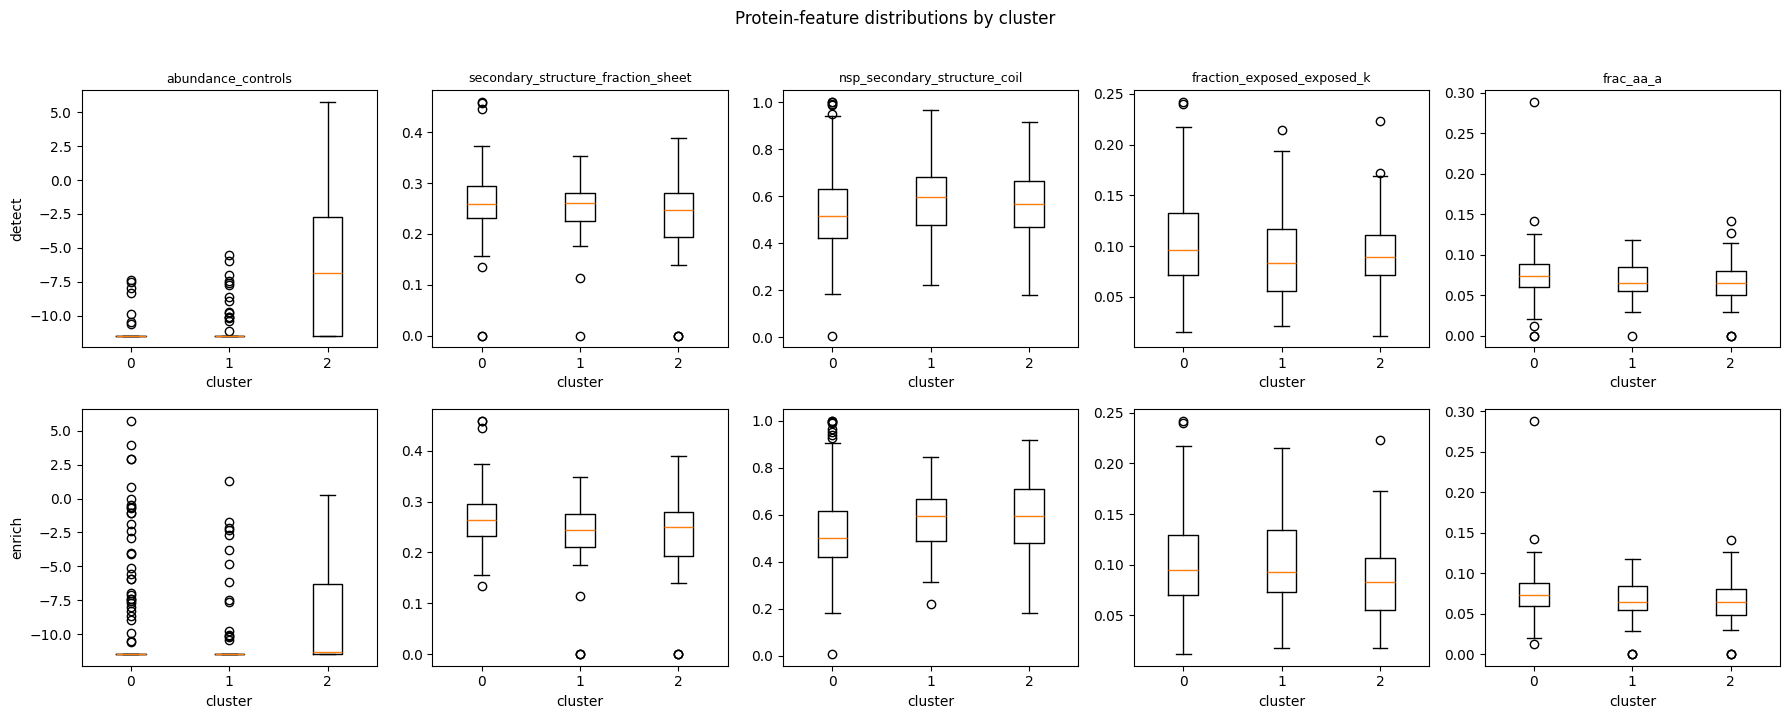

In [37]:
fig, axes = plt.subplots(2, len(PROTEIN_FEATS_6), figsize=(18, 7))
for row, label_col in enumerate(["cluster_detect", "cluster_enrich"]):
    for col, feat in enumerate(PROTEIN_FEATS_6):
        ax = axes[row, col]
        data = [g[feat].values for _, g in prof.groupby(label_col)]
        ax.boxplot(data)
        ax.set_xticklabels(sorted(prof[label_col].unique()))
        ax.set_xlabel("cluster")
        if row == 0:
            ax.set_title(feat, fontsize=9)
        ax.set_ylabel(label_col.replace("cluster_", "") if col == 0 else "")
fig.suptitle("Protein-feature distributions by cluster", y=1.02)
plt.tight_layout()
plt.show()

### Full-Feature Clustering Comparison

Repeats the zeta-sweep clustering with classifiers trained on the full 84-feature set, for
both targets, then compares each to its `PARSI_6` counterpart via adjusted Rand index and a
contingency table. With the full set, other NP features are held fixed at each protein's
first-row values during the sweep.

In [38]:
# Full 84-feature classifiers, same zeta-sweep clustering as the PARSI_6 versions.
_, resp_detect_full, resp_enrich_full = response_matrices(df, feature_columns)
cl_detect_full = cluster_response(resp_detect_full)
cl_enrich_full = cluster_response(resp_enrich_full)

detect_summary_full = cluster_summary(resp_detect_full, cl_detect_full, "detect_full")
enrich_summary_full = cluster_summary(resp_enrich_full, cl_enrich_full, "enrich_full")
print("Full-feature detection clustering:")
print(detect_summary_full)
print("\nFull-feature enrichment clustering:")
print(enrich_summary_full)

Full-feature detection clustering:
                       n  mean_prob  zeta_sensitivity
detect_full_cluster                                  
0                    190      0.173             0.066
1                     91      0.586             0.109
2                     95      0.952             0.017

Full-feature enrichment clustering:
                       n  mean_prob  zeta_sensitivity
enrich_full_cluster                                  
0                    158      0.107             0.046
1                    122      0.416             0.113
2                     96      0.833             0.058


In [39]:
def compare_clusterings(labels_a, labels_b, name_a, name_b):
    """ARI, label agreement and contingency table for two clusterings."""
    ari = adjusted_rand_score(labels_a, labels_b)
    agree = (labels_a == labels_b).mean()
    print(f"{name_a} vs {name_b}:  ARI = {ari:.3f},  same label = {agree:.1%}")
    print(
        pd.crosstab(
            pd.Series(labels_a, name=name_a),
            pd.Series(labels_b, name=name_b),
        )
    )
    print()


clusters["cluster_detect_full"] = cl_detect_full
clusters["cluster_enrich_full"] = cl_enrich_full

print("Does the 6-feature clustering reproduce the full-feature clustering?\n")
compare_clusterings(cl_detect, cl_detect_full, "parsi6_detect", "full_detect")
compare_clusterings(cl_enrich, cl_enrich_full, "parsi6_enrich", "full_enrich")

Does the 6-feature clustering reproduce the full-feature clustering?

parsi6_detect vs full_detect:  ARI = 0.715,  same label = 88.6%
full_detect      0   1   2
parsi6_detect             
0              179  19   0
1               11  64   5
2                0   8  90

parsi6_enrich vs full_enrich:  ARI = 0.481,  same label = 76.3%
full_enrich      0   1   2
parsi6_enrich             
0              156  60   2
1                2  54  17
2                0   8  77



### Proteins That Change Cluster

One table per target, listing proteins whose cluster label differs between the `PARSI_6`
and the full-feature clustering (labels are mean-probability-ordered in both).

In [40]:
def cluster_diff(target):
    """Proteins whose cluster label differs between PARSI_6 and the full feature set."""
    c6, cf = f"cluster_{target}", f"cluster_{target}_full"
    return (
        clusters.loc[clusters[c6] != clusters[cf], ["protein_id", c6, cf]]
        .rename(columns={c6: "parsi6", cf: "full"})
        .sort_values(["parsi6", "full"])
        .reset_index(drop=True)
    )


detect_diff = cluster_diff("detect")
enrich_diff = cluster_diff("enrich")

print(
    f"Detection: {len(detect_diff)}/{len(clusters)} proteins differ "
    f"between PARSI_6 and full"
)
display(detect_diff)
print(
    f"Enrichment: {len(enrich_diff)}/{len(clusters)} proteins differ "
    f"between PARSI_6 and full"
)
display(enrich_diff)

Detection: 43/376 proteins differ between PARSI_6 and full


,protein_id,parsi6,full
0,Q3ZBG0,0,1
1,Q3B7N2,0,1
2,P33672,0,1
3,P21793,0,1
4,Q2TA40,0,1
5,O46414,0,1
6,Q3T168,0,1
7,O77742,0,1
8,P80012,0,1
9,Q0VCG9,0,1


Enrichment: 89/376 proteins differ between PARSI_6 and full


,protein_id,parsi6,full
0,Q27971,0,1
1,O46415,0,1
2,G3X745,0,1
3,Q3ZBG0,0,1
4,Q3B7N2,0,1
...,...,...,...
84,P21809,2,1
85,A6H767,2,1
86,O18979,2,1
87,Q2KJD0,2,1


In [41]:
clusters_export = clusters.rename(columns={"protein_id": "entry_id"})[
    [
        "entry_id",
        "cluster_detect",
        "cluster_enrich",
        "cluster_detect_full",
        "cluster_enrich_full",
    ]
]
clusters_export.head()

,entry_id,cluster_detect,cluster_enrich,cluster_detect_full,cluster_enrich_full
0,Q3T149,2,2,1,2
1,Q3T0A3,1,1,1,1
2,Q2KJ33,1,1,1,1
3,P39873,1,1,1,1
4,Q27971,0,0,0,1


## Export Intermediate Tables

Write every result table to `data/` (created next to this notebook) as a CSV with no
index column. Run after all analysis cells above.


In [42]:
# Small result tables assembled here from arrays / paired summaries.
rfecv_reg_scores = pd.DataFrame(
    {
        "n_features": np.arange(1, len(reg_scores) + 1),
        "cv_mae": -reg_scores,
        "cv_mae_std": reg_stds,
    }
)
rfecv_reg_ranking = pd.DataFrame(
    {
        "rfecv_rank": reg_rank,
        "selected": reg_rank == 1,
        "parsimonious": reg_rank.index.isin(reg_parsimonious_features),
    }
)
rfecv_clf_scores = pd.DataFrame(
    {
        "n_features": np.arange(1, len(scores) + 1),
        "cv_roc_auc": scores,
        "cv_roc_auc_std": stds,
    }
)
cluster_summary_parsi6 = pd.concat(
    [
        detect_summary.rename_axis("cluster").assign(target="detection"),
        enrich_summary.rename_axis("cluster").assign(target="enrichment"),
    ]
).reset_index()
cluster_summary_full84 = pd.concat(
    [
        detect_summary_full.rename_axis("cluster").assign(target="detection"),
        enrich_summary_full.rename_axis("cluster").assign(target="enrichment"),
    ]
).reset_index()
cluster_feature_profile = pd.concat(
    [
        detect_profile.assign(target="detection"),
        enrich_profile.assign(target="enrichment"),
    ]
).reset_index()

exports = [
    (importance_summary_reg, "rfr_bootstrap_importance.csv", "feature"),
    (boot_imp_reg_df, "rfr_bootstrap_importance_raw.csv", "bootstrap_iter"),
    (importance_summary_clf, "rfc_bootstrap_importance.csv", "feature"),
    (boot_imp_df, "rfc_bootstrap_importance_raw.csv", "bootstrap_iter"),
    (corr_reg, "rfr_top10_feature_correlation.csv", "feature"),
    (rfecv_reg_scores, "rfecv_regression_cv_scores.csv", None),
    (rfecv_reg_ranking, "rfecv_regression_feature_ranking.csv", "feature"),
    (perm_summary, "classifier_permutation_importance.csv", "feature"),
    (rfecv_clf_scores, "rfecv_classifier_cv_scores.csv", None),
    (selected_df, "rfecv_classifier_selected_features.csv", "feature"),
    (metrics_df, "rfecv_classifier_feature_set_oof_metrics.csv", None),
    (corr6, "parsimonious6_feature_correlation.csv", "feature"),
    (clf_metrics, "parsimonious_classifier_oof_metrics.csv", None),
    (reg_metrics, "parsimonious_regression_loo_metrics.csv", None),
    (cluster_summary_parsi6, "cluster_summary_parsimonious6.csv", None),
    (cluster_summary_full84, "cluster_summary_full84.csv", None),
    (cluster_feature_profile, "cluster_feature_profile.csv", None),
    (clusters_export, "protein_clusters.csv", None),
    (detect_diff, "cluster_label_diff_detection.csv", None),
    (enrich_diff, "cluster_label_diff_enrichment.csv", None),
]
for df_to_save, fname, idx_name in exports:
    export_csv(df_to_save, fname, idx_name)

# SHAP value tables: per-feature values plus the matching feature data, so each beeswarm
# can be replotted standalone via shap.Explanation(...) without refitting the models.
shap_exports = [
    (sv_clf_pos, "clf_parsi6"),
    *((sv, f"reg_parsi6_{t}") for t, sv in sv_reg6_by_t.items()),
    *((sv, f"rfr_full84_{t}") for t, sv in shap_exp_by_t.items()),
]
for shap_exp, stem in shap_exports:
    export_shap_csv(shap_exp, stem)

  rfr_bootstrap_importance.csv                       84 x 5
  rfr_bootstrap_importance_raw.csv                  500 x 85
  rfc_bootstrap_importance.csv                       84 x 5
  rfc_bootstrap_importance_raw.csv                  500 x 85
  rfr_top10_feature_correlation.csv                  10 x 11
  rfecv_regression_cv_scores.csv                     84 x 3
  rfecv_regression_feature_ranking.csv               84 x 4
  classifier_permutation_importance.csv              84 x 5
  rfecv_classifier_cv_scores.csv                     84 x 3
  rfecv_classifier_selected_features.csv             26 x 3
  rfecv_classifier_feature_set_oof_metrics.csv        3 x 8
  parsimonious6_feature_correlation.csv               6 x 7
  parsimonious_classifier_oof_metrics.csv             3 x 8
  parsimonious_regression_loo_metrics.csv             9 x 9
  cluster_summary_parsimonious6.csv                   6 x 5
  cluster_summary_full84.csv                          6 x 5
  cluster_feature_profile.csv        

  shap_reg_parsi6_asinh_values.csv                 6768 x 6


  shap_reg_parsi6_asinh_data.csv                   6768 x 6
  shap_reg_parsi6_log2_floor_values.csv            6768 x 6
  shap_reg_parsi6_log2_floor_data.csv              6768 x 6


  shap_rfr_full84_log1p_values.csv                 6768 x 84


  shap_rfr_full84_log1p_data.csv                   6768 x 84


  shap_rfr_full84_asinh_values.csv                 6768 x 84


  shap_rfr_full84_asinh_data.csv                   6768 x 84


  shap_rfr_full84_log2_floor_values.csv            6768 x 84


  shap_rfr_full84_log2_floor_data.csv              6768 x 84
